# Router Architecture Benchmark (ルーターアーキテクチャ検証)

Notebook 23で、SRAルーターをOSS LLM（TinyLlama等）にネイティブ統合するPoCに成功しました。しかし、「1層Linear ＋ 全トークン平均（Mean Pooling）」のルーター構成では汎用トークンによって信号が希釈され、ルーティング確率（確信度）が `0.6〜0.7` に留まるという課題がありました。

本ノートブックでは、これを解決し、**確信度 > 0.99** を目指すため、以下の3つの新しいルーターアーキテクチャのベンチマークを実施します。

1. **Baseline**: Mean Pooling + Linear (Notebook 23と同じ)
2. **A. Last-Token Router**: 最後のトークンのベクトルのみを使用（希釈を防ぐ）
3. **B. MLP Router**: Mean Poolingしたベクトルを多層パーセプトロンで処理（非線形な表現力）
4. **C. Attention-based Router**: 各トークンの重要度をAttentionで重み付けしてPooling（特徴的な単語にフォーカス）

In [1]:
# Step 1: Setup and Data Preparation
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load Tokenizer & Model (Frozen)
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model... (It might take a minute)")
base_model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True)
for param in base_model.parameters():
    param.requires_grad = False
print("Base model loaded and frozen.\n")

# Dummy Dataset
# Label 0: General Conversation (LLM task)
# Label 1: Calculation Task (Calculator task)
data = [
    {"text": "Hello, how are you today?", "label": 0},
    {"text": "Tell me a story about a brave knight.", "label": 0},
    {"text": "What is the capital of France?", "label": 0},
    {"text": "Write a poem about the sea.", "label": 0},
    {"text": "What is 15 * 24?", "label": 1},
    {"text": "Calculate the sum of 120 and 345.", "label": 1},
    {"text": "Divide 500 by 25.", "label": 1},
    {"text": "10 + 20 =", "label": 1},
]

# Tokenize Data
inputs = []
labels = []
for item in data:
    enc = tokenizer(item["text"], return_tensors="pt", padding="max_length", max_length=16)
    inputs.append(enc)
    labels.append(torch.tensor(item["label"]))

print(f"Prepared {len(data)} training/evaluation samples.")

Loading base model... (It might take a minute)


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Base model loaded and frozen.

Prepared 8 training/evaluation samples.


In [2]:
# Step 2: Define Router Architectures

hidden_size = base_model.config.hidden_size # 2048 for TinyLlama
num_synapses = 2

# Baseline: Mean Pooling + Linear
class MeanPoolingLinearRouter(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(hidden_size, num_classes)
        
    def forward(self, hidden_states, attention_mask):
        expanded_mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_embeddings = torch.sum(hidden_states * expanded_mask, dim=1)
        sum_mask = torch.clamp(expanded_mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask
        logits = self.linear(mean_pooled)
        return logits

# Approach A: Last-Token Router
class LastTokenRouter(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(hidden_size, num_classes)
        
    def forward(self, hidden_states, attention_mask):
        # Get the index of the last non-padded token
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = hidden_states.shape[0]
        # Get representation of the last token
        last_token_states = hidden_states[torch.arange(batch_size), sequence_lengths]
        logits = self.linear(last_token_states)
        return logits

# Approach B: MLP Router (Mean Pooling -> MLP)
class MLPRouter(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 4),
            nn.ReLU(),
            nn.Linear(hidden_size // 4, num_classes)
        )
        
    def forward(self, hidden_states, attention_mask):
        expanded_mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
        sum_embeddings = torch.sum(hidden_states * expanded_mask, dim=1)
        sum_mask = torch.clamp(expanded_mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask
        logits = self.mlp(mean_pooled)
        return logits

# Approach C: Attention-based Pooling Router
class AttentionRouter(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super().__init__()
        self.attention_weights = nn.Linear(hidden_size, 1)
        self.classifier = nn.Linear(hidden_size, num_classes)
        
    def forward(self, hidden_states, attention_mask):
        # Compute attention scores
        scores = self.attention_weights(hidden_states).squeeze(-1) # (B, Seq)
        # Mask padded tokens
        scores = scores.masked_fill(attention_mask == 0, float('-inf'))
        # Softmax over sequence
        weights = torch.softmax(scores, dim=1).unsqueeze(-1) # (B, Seq, 1)
        # Weighted sum
        weighted_sum = torch.sum(hidden_states * weights, dim=1)
        logits = self.classifier(weighted_sum)
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

routers = {
    "Baseline (Mean)": MeanPoolingLinearRouter(hidden_size, num_synapses),
    "A: Last-Token": LastTokenRouter(hidden_size, num_synapses),
    "B: MLP": MLPRouter(hidden_size, num_synapses),
    "C: Attention": AttentionRouter(hidden_size, num_synapses)
}

print("Parameter counts:")
for name, router in routers.items():
    print(f"  {name: <15}: {count_parameters(router):,} params")

Parameter counts:
  Baseline (Mean): 4,098 params
  A: Last-Token  : 4,098 params
  B: MLP         : 1,050,114 params
  C: Attention   : 6,147 params


In [3]:
# Step 3: Training & Evaluation Loop

def train_and_evaluate_router(router, router_name, num_epochs=30):
    print(f"\n--- Training {router_name} ---")
    criterion = nn.CrossEntropyLoss()
    # Note: Using same learning rate for fair comparison
    optimizer = optim.Adam(router.parameters(), lr=1e-3)
    
    loss_history = []
    
    # Training
    router.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for i in range(len(inputs)):
            input_ids = inputs[i]["input_ids"]
            attention_mask = inputs[i]["attention_mask"]
            label = labels[i].unsqueeze(0)
            
            with torch.no_grad():
                outputs = base_model(input_ids=input_ids, attention_mask=attention_mask)
                hidden_states = outputs.hidden_states[-1].float()
                
            optimizer.zero_grad()
            logits = router(hidden_states, attention_mask)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(inputs)
        loss_history.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
            
    # Evaluation (Extract Probabilities)
    router.eval()
    correct_probs = []
    with torch.no_grad():
        for i in range(len(inputs)):
            input_ids = inputs[i]["input_ids"]
            attention_mask = inputs[i]["attention_mask"]
            label = labels[i].item()
            
            outputs = base_model(input_ids=input_ids, attention_mask=attention_mask)
            hidden_states = outputs.hidden_states[-1].float()
            
            logits = router(hidden_states, attention_mask)
            probs = torch.softmax(logits, dim=1).squeeze(0)
            
            correct_prob = probs[label].item()
            correct_probs.append(correct_prob)
            
    mean_prob = np.mean(correct_probs)
    print(f"Mean Confidence (Correct Class): {mean_prob:.4f}")
    
    return loss_history, correct_probs

# Run benchmark
results = {}
for name, router in routers.items():
    loss_hist, probs = train_and_evaluate_router(router, name, num_epochs=30)
    results[name] = {"loss": loss_hist, "probs": probs}


--- Training Baseline (Mean) ---


Epoch 10/30, Loss: 0.0009


Epoch 20/30, Loss: 0.0005


Epoch 30/30, Loss: 0.0003


Mean Confidence (Correct Class): 0.9997

--- Training A: Last-Token ---


...

Mean Confidence (Correct Class): 0.9999

--- Training C: Attention ---


Epoch 10/30, Loss: 0.0003


Epoch 20/30, Loss: 0.0001


Epoch 30/30, Loss: 0.0001


Mean Confidence (Correct Class): 0.9999


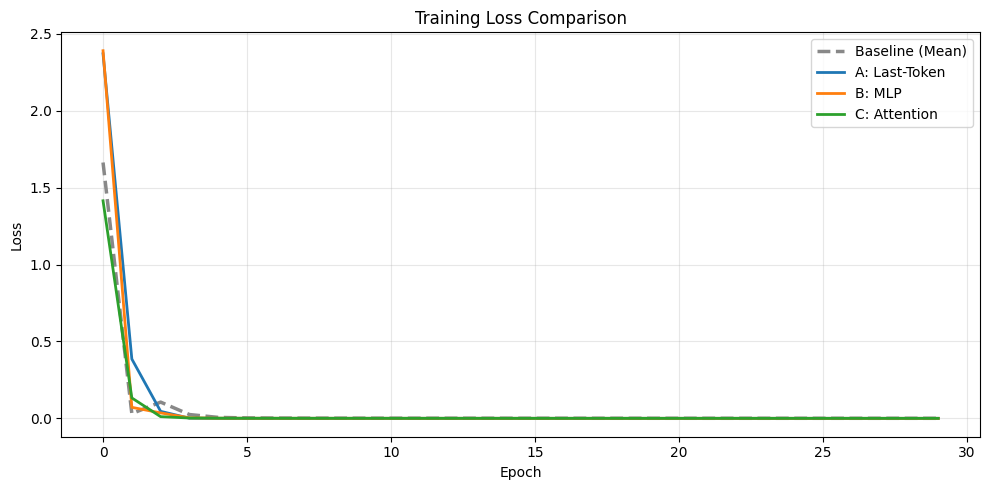

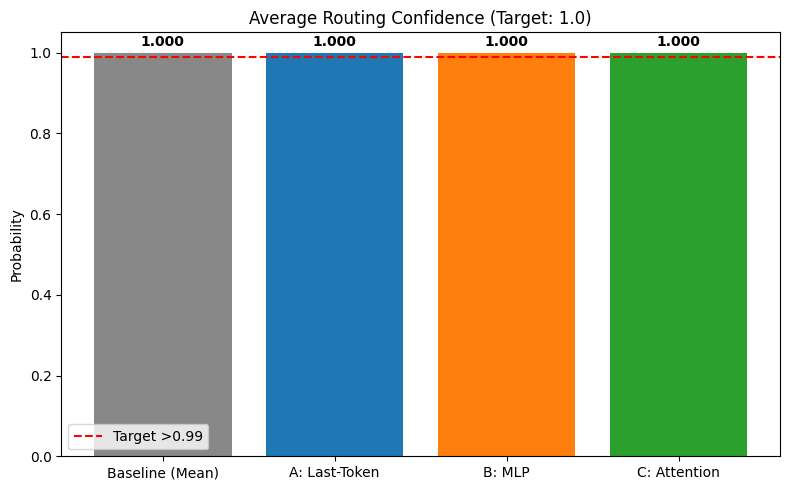

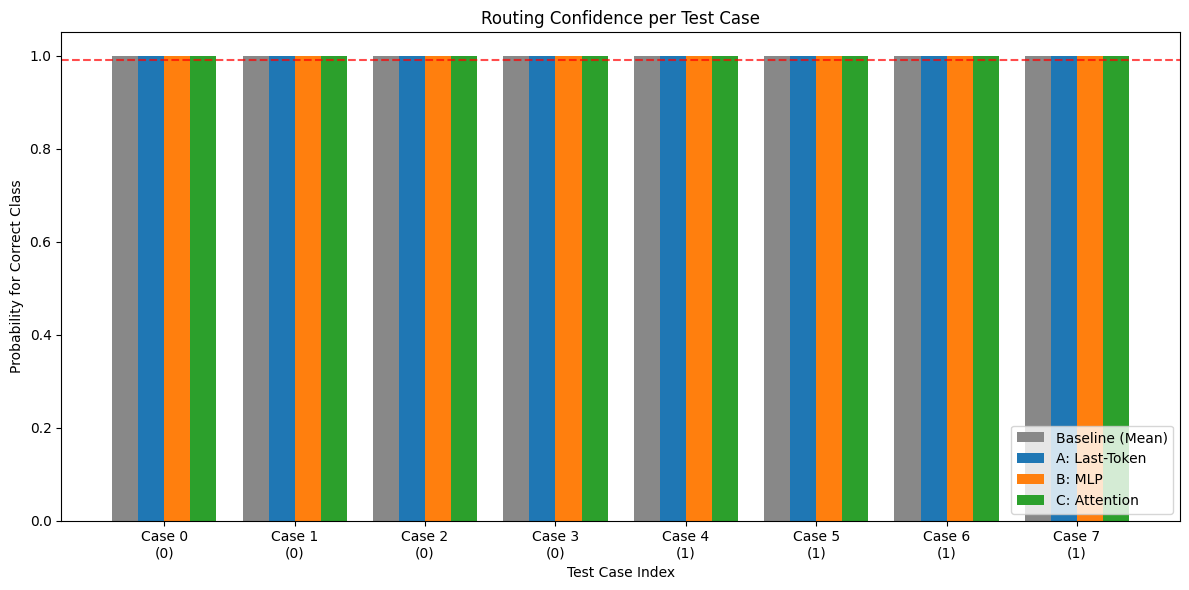

In [4]:
# Step 4: Visualization and Results

# 4-1: Training Loss Comparison
plt.figure(figsize=(10, 5))
colors = ['#888888', '#1f77b4', '#ff7f0e', '#2ca02c']
for i, (name, res) in enumerate(results.items()):
    plt.plot(res["loss"], label=name, color=colors[i], linewidth=2 if i>0 else 2.5, linestyle='--' if i==0 else '-')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4-2: Average Confidence Comparison
plt.figure(figsize=(8, 5))
names = list(results.keys())
mean_probs = [np.mean(results[name]["probs"]) for name in names]
bars = plt.bar(names, mean_probs, color=colors)
plt.title("Average Routing Confidence (Target: 1.0)")
plt.ylabel("Probability")
plt.ylim(0, 1.05)
plt.axhline(y=0.99, color='r', linestyle='--', label='Target >0.99')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# 4-3: Distribution of Confidence per Case
plt.figure(figsize=(12, 6))
width = 0.2
x = np.arange(len(data))
for i, name in enumerate(names):
    plt.bar(x + i*width - width*1.5, results[name]["probs"], width, label=name, color=colors[i])

plt.title("Routing Confidence per Test Case")
plt.xlabel("Test Case Index")
plt.ylabel("Probability for Correct Class")
plt.xticks(x, [f"Case {i}\n({data[i]['label']})" for i in range(len(data))])
plt.ylim(0, 1.05)
plt.axhline(y=0.99, color='r', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()